In [33]:
from PF2nlfff import packages,model_3D,tools,mf_module
from packages import *
from model_3D import *
from tools import *
from mf_module import *
import scipy.io
# from Loss_function import *

In [ ]:
bcube = scipy.io.loadmat('Bxyz.mat')['Expression1']
bcube = bcube.transpose(3,0,1,2)
Bcube2vtr(bcube,savepath='LL_model')
evaluate(bcube, is_eval=True)

boundary = bcube[:,:,:,0]
LL_PF = extrapolate_potential(boundary, n3=50)

LL_data = adc_shape(bcube)
PF_data = adc_shape(LL_PF)

In [ ]:
model = PICNN(PF_data)

In [15]:
# train(self, epoch=100, lr=1e-3, Delta=100, gamma=0.9):
model.L_bc = 1.e4
model.L_div = 1.e1
model.print_epoch=50
model.save_epoch=1000
model._use_mf = True
# model.L_bc = 1.e4
LR = 1.e-3
# LR = 'continue'
step_size = 40
gamma=0.99
model.train(5001, lr=LR, Delta=step_size, gamma=gamma)

Iter 00001, Loss: 9.249e+06, Loss_div: 4.370e+06,Loss_ff: 1.735e+05, Loss_bc: 4.703e+06, wall_time: 7.853e-01 sec, lr: 1.000e-03
Iter 00050, Loss: 1.494e+06, Loss_div: 6.549e+05,Loss_ff: 2.287e+05, Loss_bc: 6.104e+05, wall_time: 5.868e+01 sec, lr: 9.606e-04
Iter 00100, Loss: 1.136e+06, Loss_div: 4.336e+05,Loss_ff: 1.948e+05, Loss_bc: 5.071e+05, wall_time: 9.691e+01 sec, lr: 9.135e-04
Iter 00150, Loss: 5.596e+05, Loss_div: 2.997e+05,Loss_ff: 1.478e+05, Loss_bc: 1.117e+05, wall_time: 1.504e+02 sec, lr: 8.687e-04
Iter 00200, Loss: 4.658e+05, Loss_div: 2.678e+05,Loss_ff: 1.316e+05, Loss_bc: 6.616e+04, wall_time: 1.888e+02 sec, lr: 8.262e-04
Iter 00250, Loss: 2.538e+05, Loss_div: 1.218e+05,Loss_ff: 8.861e+04, Loss_bc: 4.318e+04, wall_time: 2.300e+02 sec, lr: 7.857e-04
Iter 00300, Loss: 1.854e+05, Loss_div: 8.341e+04,Loss_ff: 8.291e+04, Loss_bc: 1.886e+04, wall_time: 2.587e+02 sec, lr: 7.472e-04
Iter 00350, Loss: 1.656e+05, Loss_div: 7.482e+04,Loss_ff: 6.708e+04, Loss_bc: 2.352e+04, wall_tim

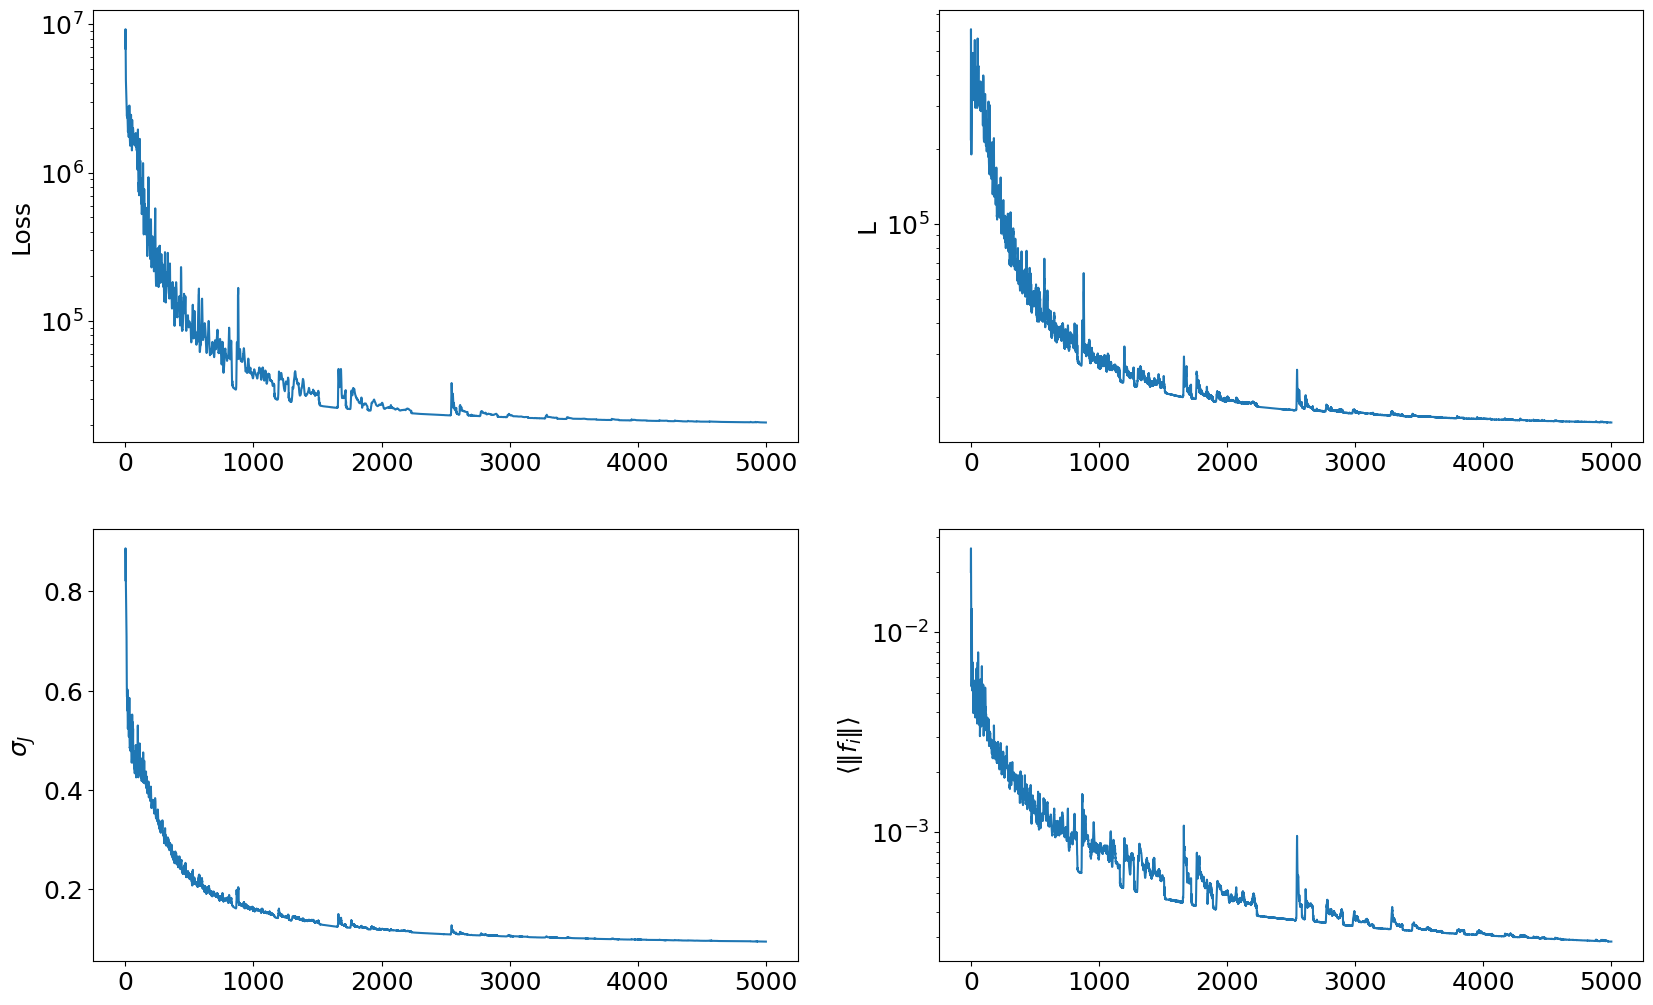

In [16]:
plt.rcParams['font.size'] = 18
plt.figure(figsize=(20,6.18*2))
plt.subplot(221)
plt.plot(model.loss_list)
plt.yscale('log')
plt.ylabel('Loss')

plt.subplot(222)
plt.plot(model.L_list)
plt.yscale('log')
plt.ylabel('L')

plt.subplot(223)
plt.plot(model.sJ_list)
plt.ylabel('$\sigma_J$')

plt.subplot(224)
plt.plot(model.fi_list)
plt.yscale('log')
plt.ylabel(r'$\left<\|f_i\|\right>$')

plt.show()

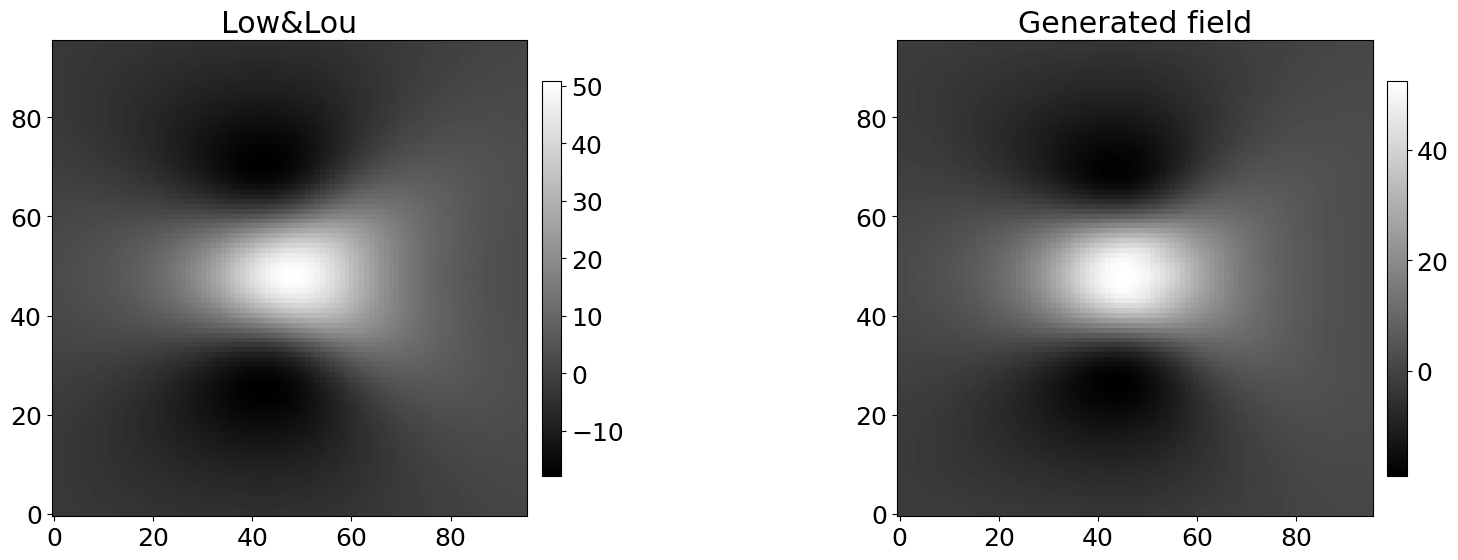

In [34]:
idir = 2
zi = 10
plt.figure(figsize=(20,6.18))
plt.subplot(121)
plt.imshow(LL_data[idir,:,:,zi],origin='lower',cmap='gray')
plt.title('Low&Lou')
plt.colorbar(fraction=0.028, pad=0.02)

plt.subplot(122)
plt.imshow(pred[idir,:,:,zi],origin='lower',cmap='gray')
plt.title('Generated field')
plt.colorbar(fraction=0.028, pad=0.02)

plt.show()